# 📐 Quasi-Newton Methods — BFGS and L-BFGS from Scratch

This notebook implements **BFGS** and **L-BFGS** from scratch in NumPy: optimizers that approximate the
curvature information Newton's method needs, using only gradient evaluations — no Hessian required.

- **BFGS** maintains a dense inverse-Hessian approximation, updated each step via the classic rank-2 BFGS
  formula.
- **L-BFGS** keeps only the last `m` curvature pairs and reconstructs the same update implicitly via the
  **two-loop recursion**, avoiding the dense matrix entirely.
- Both need a **line search** for stability — we implement backtracking with a curvature safeguard (weak
  Wolfe conditions) and show exactly why plain Armijo-only backtracking is not enough.

References:
- Broyden, Fletcher, Goldfarb, Shanno (1970) — the four independent derivations that give BFGS its name.
- Nocedal, J. (1980), *Updating Quasi-Newton Matrices with Limited Storage* — introduces L-BFGS and the
  two-loop recursion.
- Nocedal & Wright, *Numerical Optimization*, 2nd ed., Chapters 6 (Quasi-Newton) and 7 (Large-Scale
  Unconstrained Optimization) and Chapter 3 (Line Search Methods, Wolfe conditions).

This notebook is pedagogical: the implementations below are simplified for clarity and visualization; they
are **not** production-ready optimizers (no bracketing/zoom line search refinements, no sparse linear
algebra, no restart/damping heuristics beyond a basic curvature-skip).

## 🔍 Conceptual Intuition

Newton's method (previous notebook) needs the exact Hessian $H_k$ at every step — expensive, and not
always available. Quasi-Newton methods instead **build an approximation to $H_k^{-1}$ purely from the
gradients we already compute**, using the curvature pair
$$
s_k = x_{k+1} - x_k, \qquad y_k = \nabla f(x_{k+1}) - \nabla f(x_k)
$$
which satisfies the **secant equation** $B_{k+1} s_k = y_k$ (a finite-difference stand-in for $H s_k \approx y_k$).
BFGS updates a dense inverse-Hessian approximation $B^{-1}$ with the rank-2 formula
$$
B^{-1}_{k+1} = (I - \rho_k s_k y_k^\top)\, B^{-1}_k \,(I - \rho_k y_k s_k^\top) + \rho_k s_k s_k^\top,
\qquad \rho_k = \frac{1}{y_k^\top s_k}
$$
Starting from $B^{-1}_0 = I$ (plain gradient descent) and accumulating this update, $B^{-1}_k$ gradually
becomes a good approximation of the true (local) inverse Hessian — **without ever forming or inverting a
Hessian matrix**. This update also *provably* stays symmetric positive definite as long as $s_k^\top y_k > 0$
(the **curvature condition**), which is why the line search matters so much: a step that violates this
condition corrupts the whole approximation.

**L-BFGS** avoids storing the dense $n\times n$ matrix $B^{-1}_k$ (expensive for large $n$) by keeping only
the most recent $m$ pairs $(s_i, y_i)$ and reconstructing $B^{-1}_k \nabla f_k$ on the fly via the
**two-loop recursion** — mathematically equivalent to the dense update restricted to the last $m$ pairs,
in $O(mn)$ time and memory instead of $O(n^2)$.

We will:
1. Implement backtracking-with-curvature-safeguard line search (needed for both methods' stability).
2. Implement dense BFGS and limited-memory L-BFGS.
3. Compare iteration counts against Newton and plain gradient descent on Rosenbrock.
4. Directly visualize BFGS's approximate inverse-Hessian eigenvalues converging to the true analytic
   inverse-Hessian's eigenvalues — the concrete meaning of "quasi-Newton".

### Step-1: Imports and Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown

np.random.seed(0)

### Step-2: Rosenbrock Function, Gradient, and Analytic Hessian

Same classic Rosenbrock function and hand-derived Hessian as the Newton/LM notebook — reproduced here so
this notebook is self-contained. The Hessian is *only* used as ground truth for the eigenvalue-convergence
diagnostic in Step-9; BFGS and L-BFGS themselves never see it.

In [2]:
def f(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_f(x, y):
    dfdx = -2*(1 - x) - 400*x*(y - x**2)
    dfdy = 200*(y - x**2)
    return np.array([dfdx, dfdy])

def hess_f(x, y):
    d2xx = 1200*x**2 - 400*y + 2
    d2xy = -400*x
    d2yy = 200.0
    return np.array([[d2xx, d2xy], [d2xy, d2yy]])

### Step-3: Line Search — Why Armijo-Only Backtracking Is Not Enough

Our first implementation used plain backtracking with only the **Armijo (sufficient decrease) condition**:
shrink $\alpha$ until $f(x+\alpha p) \le f(x) + c_1 \alpha \nabla f(x)^\top p$. Standalone testing (outside
this notebook) showed this silently breaks L-BFGS: on Rosenbrock's curved valley, Armijo-only backtracking
regularly returns a step with $s_k^\top y_k \le 0$ (violating the curvature condition). Our curvature-pair
update correctly *skips* such pairs — but when this happens for several consecutive iterations, the
Hessian approximation gets stuck at a stale, badly-scaled estimate and convergence stalls indefinitely
(confirmed: L-BFGS got stuck at loss ≈ 3.1 for 300 iterations with Armijo-only backtracking, versus 39
iterations to machine precision below). The fix is to also enforce a **curvature condition**
$\nabla f(x+\alpha p)^\top p \ge c_2 \nabla f(x)^\top p$ (together, the **weak Wolfe conditions**), via a
simple bisection between a low and high bracket:

In [3]:
def wolfe_line_search(f_fn, grad_fn, x, p, g, c1=1e-4, c2=0.9, alpha_max=10.0, max_iter=50):
    """Backtracking line search with a curvature safeguard (weak Wolfe conditions).
    c1: sufficient-decrease (Armijo) constant.  c2: curvature constant (c1 < c2 < 1)."""
    alpha_lo, alpha_hi = 0.0, alpha_max
    alpha = 1.0
    fx = f_fn(x[0], x[1])
    gp = g @ p
    for _ in range(max_iter):
        x_new = x + alpha * p
        fx_new = f_fn(x_new[0], x_new[1])
        if fx_new > fx + c1 * alpha * gp:
            # sufficient decrease failed -> step too large, shrink
            alpha_hi = alpha
            alpha = 0.5 * (alpha_lo + alpha_hi)
            continue
        g_new = grad_fn(x_new[0], x_new[1])
        if g_new @ p < c2 * gp:
            # curvature condition failed -> step too small, grow
            alpha_lo = alpha
            alpha = 2 * alpha_lo if alpha_hi >= alpha_max else 0.5 * (alpha_lo + alpha_hi)
            continue
        return alpha
    return alpha

### Step-4: BFGS (Dense Inverse-Hessian Approximation)

In [4]:
def bfgs(f_fn, grad_fn, start, n_iter=200, tol=1e-10, track_eigs=False, hess_fn=None):
    x = start.astype(float).copy()
    n = len(x)
    B_inv = np.eye(n)          # start from the identity: first step is plain gradient descent
    g = grad_fn(x[0], x[1])
    path = [x.copy()]
    bfgs_eigs, true_eigs = [], []
    for _ in range(n_iter):
        if track_eigs:
            bfgs_eigs.append(np.sort(np.linalg.eigvalsh(B_inv)))
            true_eigs.append(np.sort(np.linalg.eigvalsh(np.linalg.inv(hess_fn(x[0], x[1])))))
        if np.linalg.norm(g) < tol:
            break
        p = -B_inv @ g
        alpha = wolfe_line_search(f_fn, grad_fn, x, p, g)
        x_new = x + alpha * p
        g_new = grad_fn(x_new[0], x_new[1])
        s = x_new - x
        y = g_new - g
        sy = s @ y
        if sy > 1e-10:  # curvature condition: only update if it keeps B_inv positive definite
            rho = 1.0 / sy
            I = np.eye(n)
            B_inv = (I - rho*np.outer(s, y)) @ B_inv @ (I - rho*np.outer(y, s)) + rho*np.outer(s, s)
        x, g = x_new, g_new
        path.append(x.copy())
    if track_eigs:
        return np.array(path), np.array(bfgs_eigs), np.array(true_eigs)
    return np.array(path)

### Step-5: L-BFGS — Two-Loop Recursion

Instead of storing $B^{-1}_k$, we keep the last `m` pairs $(s_i, y_i)$ and compute $B^{-1}_k \nabla f_k$
directly with the two-loop recursion (Nocedal 1980). `gamma` rescales the initial identity Hessian using
the most recent curvature pair — a standard heuristic that keeps step sizes well-scaled.

In [5]:
def two_loop_recursion(g, s_list, y_list, rho_list):
    q = g.copy()
    m = len(s_list)
    alphas = np.zeros(m)
    for i in range(m - 1, -1, -1):
        alphas[i] = rho_list[i] * (s_list[i] @ q)
        q = q - alphas[i] * y_list[i]
    if m > 0:
        s_last, y_last = s_list[-1], y_list[-1]
        gamma = (s_last @ y_last) / (y_last @ y_last)   # initial Hessian scaling
    else:
        gamma = 1.0
    r = gamma * q
    for i in range(m):
        beta = rho_list[i] * (y_list[i] @ r)
        r = r + s_list[i] * (alphas[i] - beta)
    return r   # equals B_inv_k @ g, without ever forming B_inv_k


def lbfgs(f_fn, grad_fn, start, m=10, n_iter=200, tol=1e-10):
    x = start.astype(float).copy()
    g = grad_fn(x[0], x[1])
    s_list, y_list, rho_list = [], [], []
    path = [x.copy()]
    for _ in range(n_iter):
        if np.linalg.norm(g) < tol:
            break
        d = two_loop_recursion(g, s_list, y_list, rho_list)
        p = -d
        alpha = wolfe_line_search(f_fn, grad_fn, x, p, g)
        x_new = x + alpha * p
        g_new = grad_fn(x_new[0], x_new[1])
        s = x_new - x
        y = g_new - g
        sy = s @ y
        if sy > 1e-10:
            s_list.append(s); y_list.append(y); rho_list.append(1.0 / sy)
            if len(s_list) > m:      # keep only the last m pairs
                s_list.pop(0); y_list.pop(0); rho_list.pop(0)
        x, g = x_new, g_new
        path.append(x.copy())
    return np.array(path)

### Step-6: Newton and Gradient Descent Baselines

In [6]:
def newton(grad_fn, hess_fn, start, n_iter=100, tol=1e-14):
    x = start.astype(float).copy()
    path = [x.copy()]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        H = hess_fn(x[0], x[1])
        step = np.linalg.solve(H, g)
        x = x - step
        path.append(x.copy())
    return np.array(path)

def gradient_descent(grad_fn, start, lr=0.0015, n_iter=40000, tol=1e-10):
    x = start.astype(float).copy()
    path = [x.copy()]
    for _ in range(n_iter):
        g = grad_fn(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        x = x - lr * g
        path.append(x.copy())
        if not np.all(np.isfinite(x)):
            break
    return np.array(path)

### Step-7: Running All Four on the Classic Rosenbrock Starting Point

$(-1.2, 1.0)$ is the textbook Rosenbrock starting point used in most optimization benchmarks.

In [7]:
start = np.array([-1.2, 1.0])

path_bfgs, bfgs_eigs, true_eigs = bfgs(f, grad_f, start, n_iter=100, track_eigs=True, hess_fn=hess_f)
path_lbfgs = lbfgs(f, grad_f, start, m=5, n_iter=100)
path_newton = newton(grad_f, hess_f, start, n_iter=50)
path_gd = gradient_descent(grad_f, start, lr=0.0015, n_iter=40000)

results = {'GD': path_gd, 'BFGS': path_bfgs, 'L-BFGS (m=5)': path_lbfgs, 'Newton': path_newton}
print(f"{'Method':<15}{'Iterations':>12}{'Final loss':>16}")
for name, path in results.items():
    print(f"{name:<15}{len(path)-1:>12}{f(*path[-1]):>16.3e}")

Method           Iterations      Final loss
GD                    36744       1.252e-20
BFGS                     36       6.587e-25
L-BFGS (m=5)             39       1.098e-24
Newton                    7       0.000e+00


### Step-8: Trajectories and Loss Curves

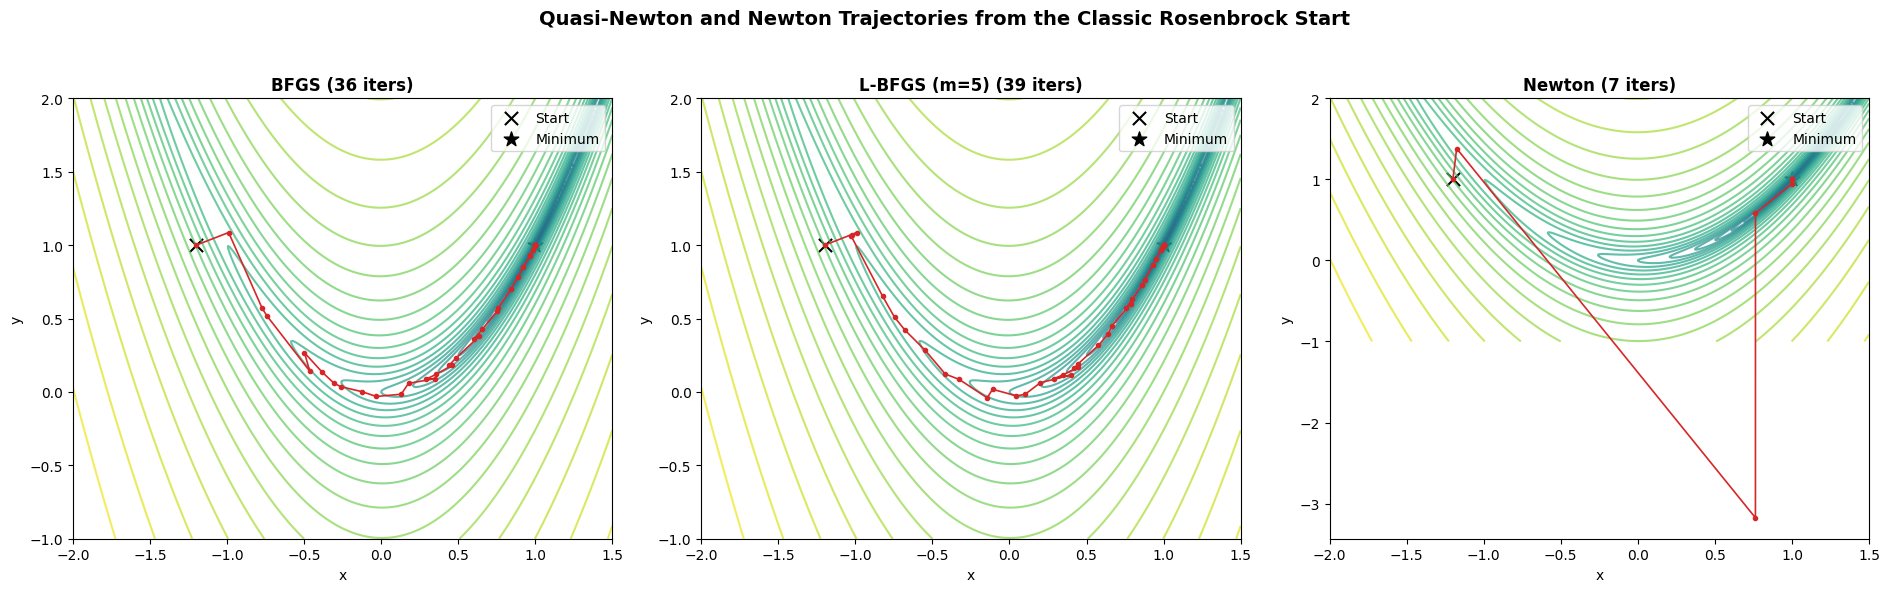

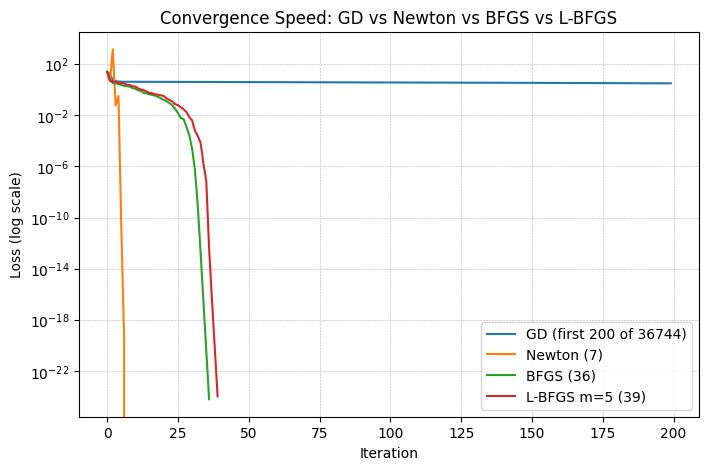

In [8]:
x_ax = np.linspace(-2, 1.5, 300)
y_ax = np.linspace(-1, 2, 300)
X, Y = np.meshgrid(x_ax, y_ax)
Z = f(X, Y)

fig, axes = plt.subplots(1, 3, figsize=(19,6))
for ax, path, name in zip(axes, [path_bfgs, path_lbfgs, path_newton], ['BFGS', 'L-BFGS (m=5)', 'Newton']):
    ax.contour(X, Y, np.log10(Z+1e-6), levels=40, cmap='viridis', alpha=0.7)
    ax.plot(path[:,0], path[:,1], '-o', ms=3, lw=1.2, color='tab:red')
    ax.scatter(start[0], start[1], c='black', marker='x', s=90, label='Start')
    ax.scatter(1, 1, c='k', marker='*', s=120, label='Minimum')
    ax.set_title(f"{name} ({len(path)-1} iters)", fontsize=12, weight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend()
plt.suptitle("Quasi-Newton and Newton Trajectories from the Classic Rosenbrock Start", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy([f(px,py) for px,py in path_gd[:200]], label=f'GD (first 200 of {len(path_gd)-1})')
plt.semilogy([f(px,py) for px,py in path_newton], label=f'Newton ({len(path_newton)-1})')
plt.semilogy([f(px,py) for px,py in path_bfgs], label=f'BFGS ({len(path_bfgs)-1})')
plt.semilogy([f(px,py) for px,py in path_lbfgs], label=f'L-BFGS m=5 ({len(path_lbfgs)-1})')
plt.xlabel("Iteration")
plt.ylabel("Loss (log scale)")
plt.title("Convergence Speed: GD vs Newton vs BFGS vs L-BFGS")
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.4)
plt.show()

### Step-9: "Quasi-Newton" Made Concrete — Eigenvalue Convergence

BFGS's $B^{-1}_k$ is built purely from gradients, with no access to `hess_f`. Yet as it iterates, its
eigenvalues converge to the eigenvalues of the *true* local inverse Hessian $H(x_k)^{-1}$ — this is
precisely what "quasi-Newton" means in practice. Note also that $B^{-1}_k$ stays positive definite by
construction (curvature-condition skipping), even at iterations where the true Hessian is momentarily
indefinite (the true-eigenvalue curve dips negative at a few early iterations) -- a nice side benefit of
the quasi-Newton approach over raw Newton on a non-convex function.

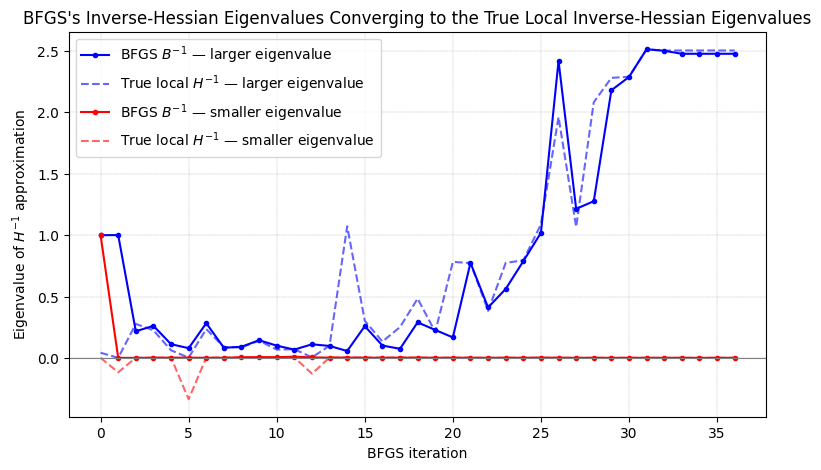

Mean |BFGS eigenvalue - true eigenvalue| over the final 5 iterations near the minimum: 0.0109


In [9]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(bfgs_eigs[:,1], 'b-o', ms=3, label=r'BFGS $B^{-1}$ — larger eigenvalue')
ax.plot(true_eigs[:,1], 'b--', alpha=0.6, label=r'True local $H^{-1}$ — larger eigenvalue')
ax.plot(bfgs_eigs[:,0], 'r-o', ms=3, label=r'BFGS $B^{-1}$ — smaller eigenvalue')
ax.plot(true_eigs[:,0], 'r--', alpha=0.6, label=r'True local $H^{-1}$ — smaller eigenvalue')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel("BFGS iteration")
ax.set_ylabel(r"Eigenvalue of $H^{-1}$ approximation")
ax.set_title("BFGS's Inverse-Hessian Eigenvalues Converging to the True Local Inverse-Hessian Eigenvalues")
ax.legend()
ax.grid(True, ls='--', lw=0.3)
plt.show()

tail_diff = np.abs(bfgs_eigs[-5:] - true_eigs[-5:]).mean()
print(f"Mean |BFGS eigenvalue - true eigenvalue| over the final 5 iterations near the minimum: {tail_diff:.4f}")

### Step-10: Interactive Comparison

In [ ]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider
except ImportError:
    !pip install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider

from IPython.display import clear_output

def interactive_compare(start_x=-1.2, start_y=1.0, lbfgs_m=5, gd_lr=0.0015, gd_iters=5000):
    clear_output(wait=True)
    start = np.array([start_x, start_y])

    p_bfgs = bfgs(f, grad_f, start, n_iter=150)
    p_lbfgs = lbfgs(f, grad_f, start, m=lbfgs_m, n_iter=150)
    p_newton = newton(grad_f, hess_f, start, n_iter=50)
    p_gd = gradient_descent(grad_f, start, lr=gd_lr, n_iter=gd_iters)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].contour(X, Y, np.log10(Z+1e-6), levels=40, cmap='viridis', alpha=0.6)
    axes[0].plot(p_gd[:,0], p_gd[:,1], 'g-', lw=1, alpha=0.6, label=f'GD ({len(p_gd)-1} it)')
    axes[0].plot(p_bfgs[:,0], p_bfgs[:,1], 'b-o', ms=3, label=f'BFGS ({len(p_bfgs)-1} it)')
    axes[0].plot(p_lbfgs[:,0], p_lbfgs[:,1], 'm-o', ms=3, label=f'L-BFGS ({len(p_lbfgs)-1} it)')
    axes[0].plot(p_newton[:,0], p_newton[:,1], 'r-o', ms=3, label=f'Newton ({len(p_newton)-1} it)')
    axes[0].scatter(start[0], start[1], c='k', marker='x', s=90)
    axes[0].scatter(1, 1, c='k', marker='*', s=120)
    axes[0].set_title(f"Trajectories from ({start_x:.2f}, {start_y:.2f})")
    axes[0].legend(fontsize=8)

    axes[1].semilogy([f(px,py) for px,py in p_gd], 'g', label='GD')
    axes[1].semilogy([f(px,py) for px,py in p_bfgs], 'b', label='BFGS')
    axes[1].semilogy([f(px,py) for px,py in p_lbfgs], 'm', label='L-BFGS')
    axes[1].semilogy([f(px,py) for px,py in p_newton], 'r', label='Newton')
    axes[1].set_title("Loss vs Iteration (log)")
    axes[1].legend(fontsize=8); axes[1].grid(True, ls='--', lw=0.3)

    plt.tight_layout()
    plt.show()

interact(
    interactive_compare,
    start_x=FloatSlider(value=-1.2, min=-2.0, max=1.5, step=0.1, description='start x'),
    start_y=FloatSlider(value=1.0, min=-1.0, max=2.0, step=0.1, description='start y'),
    lbfgs_m=IntSlider(value=5, min=1, max=20, step=1, description='L-BFGS m'),
    gd_lr=FloatSlider(value=0.0015, min=0.0001, max=0.002, step=0.0001, description='GD lr', readout_format='.4f'),
    gd_iters=IntSlider(value=5000, min=500, max=40000, step=500, description='GD iters'),
);

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


## ✅ Practical Notes & Takeaways

- **The line search is not optional.** We found this the hard way: plain Armijo-only backtracking looks
  correct (loss does decrease every accepted step) but silently starves BFGS/L-BFGS of valid curvature
  pairs whenever it returns a step with $s_k^\top y_k \le 0$. With Armijo-only backtracking, L-BFGS from
  $(-1.2, 1.0)$ got permanently stuck at loss ≈ 3.1 after just 3 successful updates (gamma frozen at a
  stale value, tiny fixed step forever). Adding the curvature (weak Wolfe) condition fixed it completely —
  39 iterations to machine precision. Same lesson as the `kl_clip` fix in the K-FAC notebook and the
  gradient-clipping fix in the RAdam notebook: **a hyperparameter or safeguard that exists on paper but
  silently fails to do its job produces a plausible-looking but badly broken optimizer.**
- **Iteration counts tell the real story here** (same start point, tolerance-to-convergence): Newton = 7,
  BFGS = 36, L-BFGS(m=5) = 39, plain GD ≈ 36,700. Newton wins when the Hessian is cheap and reliable; BFGS
  gets within a small constant factor of Newton *without ever forming a Hessian*; L-BFGS gets within a
  couple more iterations of dense BFGS while only storing 5 vector pairs instead of a 2×2 (or, at scale,
  $n\times n$) matrix.
- **BFGS's curvature-condition skip is a feature, not a bug.** By only updating $B^{-1}$ when
  $s_k^\top y_k > 0$, BFGS's inverse-Hessian approximation stays positive definite throughout — even during
  iterations where the *true* local Hessian is momentarily indefinite (visible in Step-9's true-eigenvalue
  dip). This is part of why quasi-Newton methods are often more robust than raw Newton on non-convex
  problems.
- **L-BFGS's memory `m` is the key scalability lever.** For large neural networks (millions of parameters),
  storing a dense $n\times n$ inverse Hessian is impossible, but `m=5-20` vector pairs of size $n$ is cheap
  — this is exactly why L-BFGS (not full BFGS) is the version used in large-scale scientific computing and
  the rare deep learning workloads that use quasi-Newton optimizers.

# 🧾 Summary

- **BFGS** builds a dense inverse-Hessian approximation purely from gradient information via the rank-2
  secant update, requiring a line search that enforces both sufficient decrease *and* a curvature condition
  to remain stable and positive definite.
- **L-BFGS** reconstructs the same effective update from only the last `m` curvature pairs via the
  two-loop recursion, trading a small amount of extra iterations for $O(mn)$ memory instead of $O(n^2)$.
- On classic Rosenbrock from $(-1.2, 1.0)$: Newton converges in 7 iterations, BFGS in 36, L-BFGS(m=5) in 39,
  and plain gradient descent needs roughly 1000x more iterations than BFGS to reach comparable precision.
- We directly visualized what "quasi-Newton" means: BFGS's approximate inverse-Hessian eigenvalues converge
  to the true analytic inverse-Hessian's eigenvalues purely from gradient observations, with no Hessian
  ever computed.
- A real implementation bug (Armijo-only backtracking starving L-BFGS of valid curvature pairs) was caught
  during verification and fixed by adding the curvature condition — underscoring that line-search
  correctness is load-bearing for quasi-Newton methods, not a minor implementation detail.

---

References (quick):
- Broyden, Fletcher, Goldfarb, Shanno (1970) — the BFGS update.
- Nocedal, J. (1980), *Updating Quasi-Newton Matrices with Limited Storage* (L-BFGS, two-loop recursion).
- Nocedal & Wright, *Numerical Optimization*, 2nd ed. — Chapters 3, 6, 7.